# Anomaly Detection & Time Series

---

## Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.

**Anomaly Detection** is the process of identifying data points, events, or observations that deviate significantly from the dataset's normal behavior. 

* **Point Anomalies:** A single data instance is considered anomalous with respect to the rest of the data. 
    * *Example:* A credit card transaction for $50,000 when the user’s typical spending is under $100.
* **Contextual Anomalies:** An instance is anomalous only in a specific context (e.g., time or location). 
    * *Example:* A temperature reading of 30°C is normal for summer but an anomaly if recorded in the middle of winter.
* **Collective Anomalies:** A collection of related data instances is anomalous as a whole, even if individual points might seem normal on their own. 
    * *Example:* A sequence of rapid login attempts from different locations within seconds, suggesting a coordinated cyber attack.

---

## Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

| Feature | Isolation Forest | DBSCAN | Local Outlier Factor (LOF) |
| :--- | :--- | :--- | :--- |
| **Approach** | Isolates observations by randomly selecting a feature and split value. Anomalies have shorter paths in the tree. | A density-based clustering algorithm. Points in low-density areas are labeled as noise/outliers. | Measures the local density deviation of a point compared to its neighbors to find outliers. |
| **Use Case** | High-dimensional datasets where efficiency is key; great for global anomalies. | Datasets with clusters of varying shapes; helps find outliers while grouping data. | Useful for datasets with regions of different densities; detects "local" outliers. |

---

## Question 3: What are the key components of a Time Series? Explain each with one example.

* **Trend:** The long-term increase or decrease in the data over time. 
    * *Example:* The steady rise in global temperatures over the last century.
* **Seasonality:** Regular, repeating patterns that occur at fixed intervals (e.g., daily, monthly). 
    * *Example:* An increase in ice cream sales every summer.
* **Cyclicity:** Fluctuations that occur over longer periods and do not have a fixed frequency. 
    * *Example:* Economic boom and recession periods over a decade.
* **Residual/Noise:** Random, unpredictable variation remaining after removing trend and seasonality. 
    * *Example:* A sudden drop in sales due to an unpredicted natural disaster.

---

## Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

A **Stationary** time series is one whose statistical properties (mean, variance, and autocorrelation) do not change over time.

* **Testing:** * **Visual Inspection:** Plotting data to check for trends.
    * **ADF (Augmented Dickey-Fuller) Test:** A statistical test where a p-value < 0.05 suggests stationarity.
* **Transformation:** * **Differencing:** Subtracting the current value from the previous value to remove trend.
    * **Log Transformation:** Applying a logarithm to stabilize variance.

---

## Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

* **AR (Auto-Regressive):** Predicts future values based on past values. Best for data with strong internal correlation.
* **MA (Moving Average):** Predicts future values based on past forecast errors. Useful for smoothing random noise.
* **ARIMA:** Combines AR and MA with "Integration" (differencing) to handle non-stationary data.
* **SARIMA:** Extends ARIMA by adding seasonal components (Seasonal AR, MA, and Differencing).
* **SARIMAX:** A SARIMA model that includes **Exogenous** variables (external factors like weather or holidays).

## Question 6: Time Series Decomposition (AirPassengers)

In [2]:
import pandas as pd

# Load dataset
import pandas as pd

# Relative paths (no hardcoding full path)
air_path = "clustering_&_time_series_dataset/AirPassengers.csv"
taxi_path = "clustering_&_time_series_dataset/NYC_taxi_fare_data.csv"

# Load datasets
air_df = pd.read_csv(air_path)
taxi_df = pd.read_csv(taxi_path)

# Display top 2 rows
print("AirPassengers Dataset:")
print(air_df.head(2))

print("\nNYC Taxi Fare Dataset:")
print(taxi_df.head(2))

/var/folders/f1/c0fv21ks3j11qdb1x5c6217h0000gn/T/ipykernel_8113/636656573.py:12: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  taxi_df = pd.read_csv(taxi_path)


AirPassengers Dataset:
     Month  #Passengers
0  1949-01          112
1  1949-02          118

NYC Taxi Fare Dataset:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0       1.0  2020-01-01 00:28:15   2020-01-01 00:33:03              1.0   
1       1.0  2020-01-01 00:35:39   2020-01-01 00:43:04              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            1.2         1.0                  N           238           239   
1            1.2         1.0                  N           239           238   

   payment_type  fare_amount  extra  mta_tax  tip_amount  tolls_amount  \
0           1.0          6.0    3.0      0.5        1.47           0.0   
1           1.0          7.0    3.0      0.5        1.50           0.0   

   improvement_surcharge  total_amount  congestion_surcharge  
0                    0.3         11.27                   2.5  
1                    0.3         12.30                   2.5  


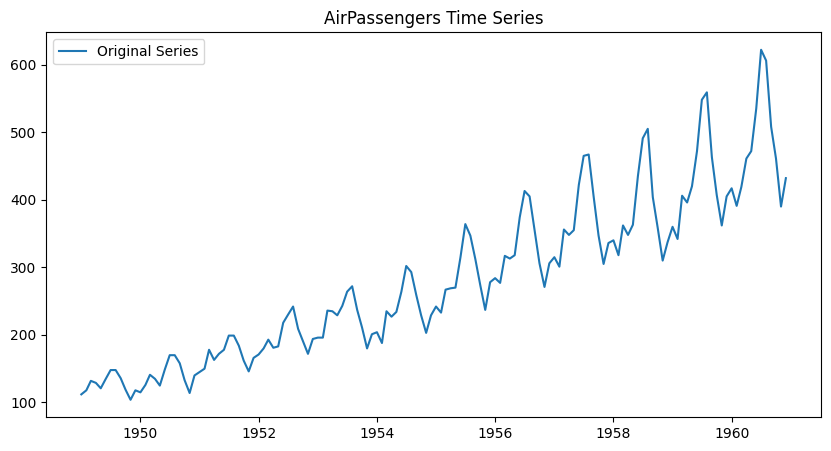

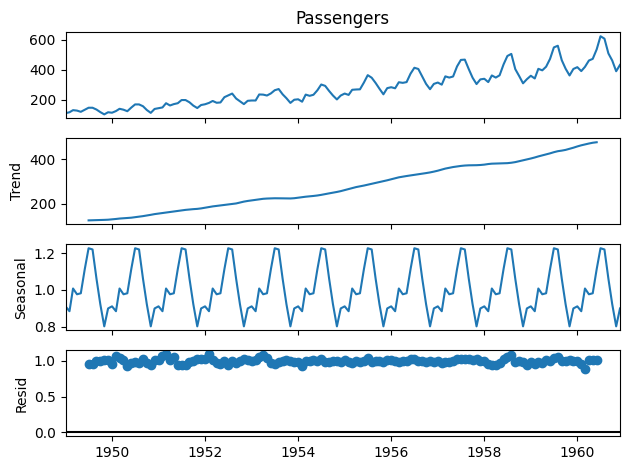

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
air_df = pd.read_csv(air_path)

# Convert Month to datetime
air_df['Month'] = pd.to_datetime(air_df['Month'])

# Set index
air_df.set_index('Month', inplace=True)

# Rename column (cleaner)
air_df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Plot original series
plt.figure(figsize=(10,5))
plt.plot(air_df['Passengers'], label='Original Series')
plt.title('AirPassengers Time Series')
plt.legend()
plt.show()

# Decomposition
decomposition = seasonal_decompose(air_df['Passengers'], model='multiplicative')

# Plot components
decomposition.plot()
plt.show()

### Question 7: Isolation Forest (NYC Taxi Fare)

### Clean the dataset

In [4]:
import pandas as pd

# Load with warning fix
taxi_df = pd.read_csv(taxi_path, low_memory=False)

# Select useful numeric columns
cols = ['trip_distance', 'fare_amount', 'total_amount']

# Drop missing values
taxi_clean = taxi_df[cols].dropna()

# Remove extreme outliers (optional but improves results)
taxi_clean = taxi_clean[(taxi_clean['fare_amount'] > 0) &
                        (taxi_clean['trip_distance'] > 0)]

### 2 Features (Visualization)

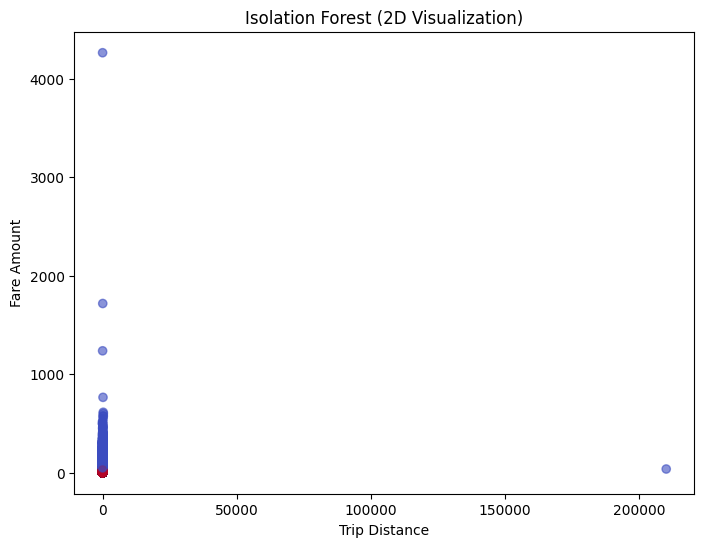

In [5]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Use 2 features
X_2d = taxi_clean[['trip_distance', 'fare_amount']]

# Train model
model = IsolationForest(contamination=0.05, random_state=42)
taxi_clean['anomaly_2d'] = model.fit_predict(X_2d)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(
    taxi_clean['trip_distance'],
    taxi_clean['fare_amount'],
    c=taxi_clean['anomaly_2d'],
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("Isolation Forest (2D Visualization)")
plt.show()

### Question 8: SARIMA Forecasting

/Users/vedikaagrawal/Documents/data_science_repo/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/vedikaagrawal/Documents/data_science_repo/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


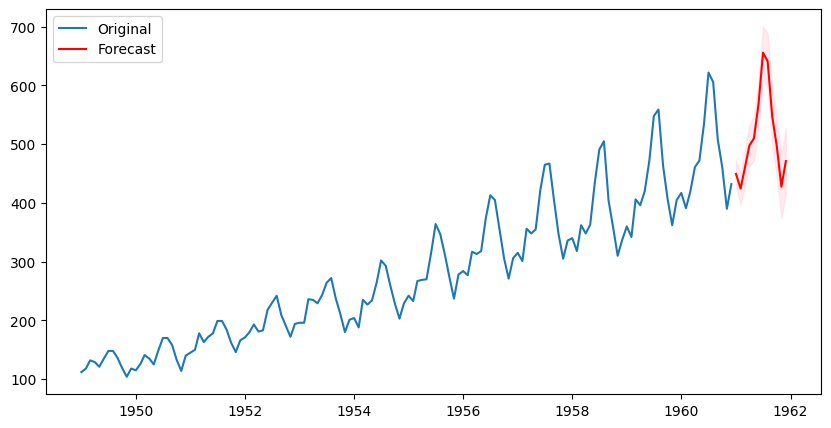

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Load dataset
air_df = pd.read_csv(air_path)

# Preprocess
air_df['Month'] = pd.to_datetime(air_df['Month'])
air_df.set_index('Month', inplace=True)
air_df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# -------------------------------
# Train SARIMA Model
# -------------------------------
model = SARIMAX(
    air_df['Passengers'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

# -------------------------------
# Forecast next 12 months
# -------------------------------
forecast_obj = results.get_forecast(steps=12)
conf_int = forecast_obj.conf_int()

# -------------------------------
# Plot results
# -------------------------------
plt.figure(figsize=(10,5))
plt.plot(air_df['Passengers'], label='Original')
plt.plot(forecast_obj.predicted_mean, label='Forecast', color='red')
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color='pink',
    alpha=0.3
)

plt.legend()
plt.show()

### Quesion 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

/Users/vedikaagrawal/Documents/data_science_repo/venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


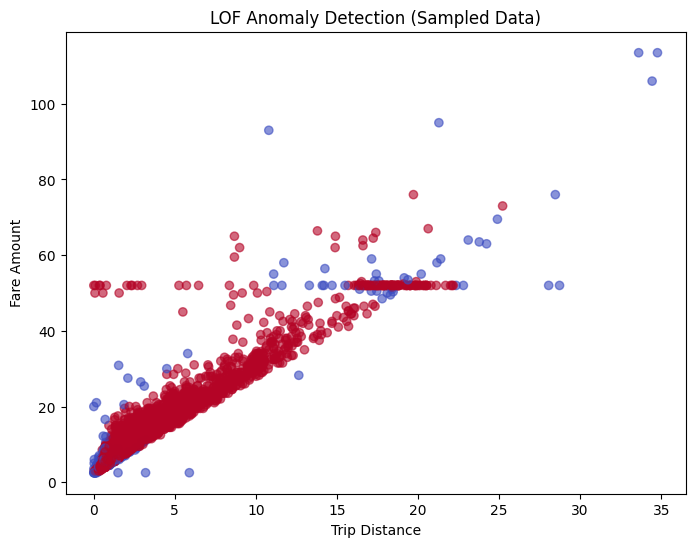

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# -------------------------------
# Step 1: Load dataset
# -------------------------------
taxi_path = "clustering_&_time_series_dataset/NYC_taxi_fare_data.csv"
taxi_df = pd.read_csv(taxi_path, low_memory=False)

# -------------------------------
# Step 2: Clean dataset
# -------------------------------
cols = ['trip_distance', 'fare_amount']

taxi_clean = taxi_df[cols].dropna()

# Remove invalid values
taxi_clean = taxi_clean[
    (taxi_clean['trip_distance'] > 0) &
    (taxi_clean['fare_amount'] > 0)
]

# -------------------------------
# Step 3: Sampling (IMPORTANT for speed)
# -------------------------------
taxi_sample = taxi_clean.sample(n=5000, random_state=42)

X_lof = taxi_sample[['trip_distance', 'fare_amount']]

# -------------------------------
# Step 4: Apply LOF
# -------------------------------
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
y_pred_lof = lof.fit_predict(X_lof)

# Add results
taxi_sample['anomaly_lof'] = y_pred_lof

# -------------------------------
# Step 5: Visualization
# -------------------------------
plt.figure(figsize=(8,6))

plt.scatter(
    taxi_sample['trip_distance'],
    taxi_sample['fare_amount'],
    c=taxi_sample['anomaly_lof'],
    cmap='coolwarm',
    alpha=0.6
)

plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title("LOF Anomaly Detection (Sampled Data)")

plt.show()

## Question 10: Real-time Data Science Workflow for Power Grid Monitoring

You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.

---

### 1. Anomaly Detection in Streaming Data

To detect anomalies in real-time data, I would use **Isolation Forest** because:
- It is efficient and scalable for large datasets
- It works well with streaming data
- It can quickly detect unusual patterns like sudden spikes or drops in energy usage

Alternative methods:
- **Local Outlier Factor (LOF):** Useful for detecting local anomalies
- **DBSCAN:** Useful for cluster-based anomaly detection

---

### 2. Time Series Model for Forecasting

For short-term forecasting, I would use **SARIMAX** because:
- It captures both trend and seasonality in time series data
- It allows inclusion of external features like weather and region
- It is suitable for time-dependent data like energy consumption

---

### 3. Model Validation and Monitoring

To ensure model performance:
- Use evaluation metrics like:
  - **MAE (Mean Absolute Error)** and **RMSE (Root Mean Squared Error)** for forecasting
  - **Precision, Recall, and ROC-AUC** for anomaly detection

- Continuously monitor:
  - Model performance over time
  - Data drift and concept drift
  - Sudden drops in accuracy

- Retrain the model periodically using updated data

---

### 4. Business Impact

This solution helps the company to:
- Prevent power outages by detecting anomalies early
- Optimize energy distribution across regions
- Reduce operational costs
- Improve reliability and efficiency of the power grid
